# Tutorial 200: Conditional Flow Matching on Synthetic Data

In Tutorial 100 the model learned one fixed map — bottom moon to top moon. Here we train a model that learns two different maps depending
on conditions.

We split the top moon into two sub-populations:
- **Condition A** (`label='0'`): left half of the top moon (x < 0)
- **Condition B** (`label='2'`): right half of the top moon (x ≥ 0)

The source is the bottom moon (`label='1'`). At inference we tell the model which
condition we want and it tries to push the source cells to the correct target half.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import types
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder

from sc_flow.trainer._trainer import FlowTrainer
from sc_flow.backends.torch.nn import MLPUnconditionalVF
from sc_flow.backends.torch.coupling import independent_coupling
from sc_flow.backends.torch.probability_paths import LinearGaussianProbabilityPath
from sc_flow.backends.torch.solvers import ODESolver
from sc_flow import methods as basemethods
from sc_flow.dataset.toy_data import get_toy_dataset
from sc_flow.data import DataManager, MatchedData
from sc_flow.data.samplers import FTrainSampler

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## Section 1: Inline Components

`BaseMethod` is defined inline because this branch does not have it. This section will be removed later and everything else will bechanged accordingly.

In [ ]:
class BaseMethod(basemethods.FlowMatching):
    """Minimal flow matching implementation used in this tutorial."""

    def __init__(self, vf, probability_path, time_sampler, solver, match_fn, opt=None, **kwargs):
        self.vf = vf
        self.probability_path = probability_path
        self.time_sampler = time_sampler
        self.match_fn = match_fn
        self.solver = solver
        self.opt = opt(self.vf.parameters(), lr=5e-4)
        self._is_trained = False
        self.vf_step_fn = self._get_vf_step_fn()

    def _get_vf_step_fn(self):
        def vf_step_fn(time, source, target, conditions):
            def loss_fn(t, src, tgt, cond):
                x_t = self.probability_path.compute_xt(t, src, tgt)
                v_t = self.vf(t, x_t, cond, src)
                u_t = self.probability_path.compute_ut(t, x_t, src, tgt)
                return torch.mean((v_t - u_t) ** 2)

            self.opt.zero_grad()
            loss = loss_fn(time, source, target, conditions)
            loss.backward()
            self.opt.step()
            return loss

        return vf_step_fn

    def step_fn(self, batch):
        """Compute one training step and return the loss tensor."""
        source = batch["src_cell_data"]
        target = batch["tgt_cell_data"]
        condition = batch.get("condition")
        time = self.time_sampler(source.shape[0])
        src_ixs, tgt_ixs = self.match_fn(source, target)
        # Reindex condition rows to match the target reordering from coupling
        if condition is not None:
            condition = {k: v[tgt_ixs] for k, v in condition.items()}
        return self.vf_step_fn(time, source[src_ixs], target[tgt_ixs], condition)

    def train_step(self, batch, prng_key=None):
        """Run one gradient step and return the scalar loss."""
        return float(self.step_fn(batch).cpu())

    def predict(self, x, condition=None, **kwargs):
        """Integrate ODE from t=0 to t=1 under the given condition.

        A fresh ODESolver is created per call
        """
        time = torch.linspace(0.0, 1.0, 101)
        solver = ODESolver(dynamics=self.vf, method="euler", vf_kwargs={"condition_dict": condition})
        return solver.solve(x, time, rtol=1e-6, atol=1e-7)

    def predict_trajectory(self, x, condition=None, n_steps: int = 20):
        """Return the full ODE trajectory under the given condition.

        Shape: (n_steps, n_cells, n_dims). Used for visualising how cells
        move from source (t=0) to target (t=1) under each condition.
        """
        time = torch.linspace(0.0, 1.0, n_steps)
        solver = ODESolver(dynamics=self.vf, method="euler", vf_kwargs={"condition_dict": condition})
        return solver.solve(x, time, rtol=1e-5, atol=1e-6, return_trajectory=True)


def uniform_time_sampler(n: int) -> torch.Tensor:
    """Sample n uniform random times in [0, 1]."""
    return torch.rand(size=(n,))

## Section 2: Data

We generate the two-moons dataset and split the top moon (label `'0'`) into two
sub-populations by x-coordinate:

- `x < 0` → keeps label `'0'` (left half)
- `x ≥ 0` → relabelled `'2'` (right half)

We then one-hot encode all three labels and store the lookup table in `adata.uns['labels']`.

In [4]:
dataset = get_toy_dataset("moons", n_samples=10_000, noise=0.1, random_state=SEED)
adata = dataset.adata

# Move labels to obs for DataManager
adata.obs["label"] = np.array(adata.obsm["Y"]).ravel()

# Split bottom moon (label '0') into left half (keep '0') and right half (rename '2')
adata.obs["label"] = adata.obs["label"].astype(str)
right_mask = (adata.obs["label"] == "0") & (np.array(adata.X)[:, 0] >= 0)
adata.obs.loc[right_mask, "label"] = "2"

print("Label counts:")
print(adata.obs["label"].value_counts())

# One-hot encode all labels and store in uns
encoder = OneHotEncoder(sparse_output=False)
unique_labels = np.array(sorted(adata.obs["label"].unique())).reshape(-1, 1)
one_hots = encoder.fit_transform(unique_labels)
adata.uns["labels"] = {str(lbl[0]): vec for lbl, vec in zip(unique_labels, one_hots, strict=False)}

print("\nCondition embeddings (one-hot):")
for k, v in adata.uns["labels"].items():
    print(f"  label '{k}': {v}")

Label counts:
label
1    5000
2    2504
0    2496
Name: count, dtype: int64

Condition embeddings (one-hot):
  label '0': [1. 0. 0.]
  label '1': [0. 1. 0.]
  label '2': [0. 0. 1.]


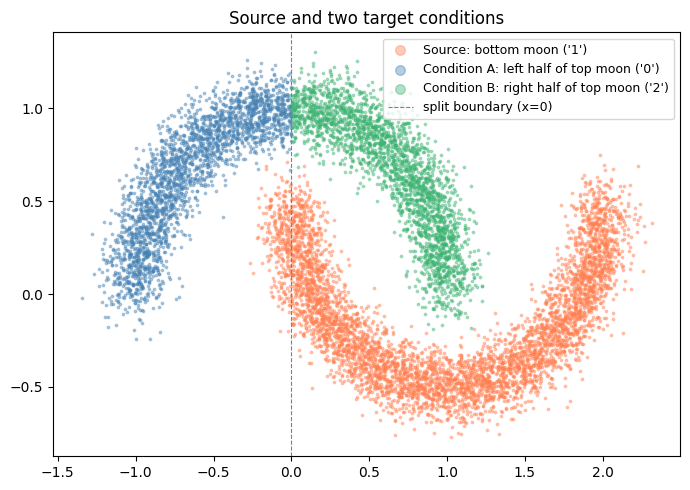

In [5]:
X = np.array(adata.X)
labels = adata.obs["label"].values

colors = {"1": "coral", "0": "steelblue", "2": "mediumseagreen"}
names = {
    "1": "Source: bottom moon ('1')",
    "0": "Condition A: left half of top moon ('0')",
    "2": "Condition B: right half of top moon ('2')",
}

fig, ax = plt.subplots(figsize=(7, 5))
for lbl in ["1", "0", "2"]:
    mask = labels == lbl
    ax.scatter(X[mask, 0], X[mask, 1], s=3, alpha=0.4, color=colors[lbl], label=names[lbl])
ax.axvline(0, color="gray", lw=0.8, linestyle="--", label="split boundary (x=0)")
ax.set_title("Source and two target conditions")
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.show()

## Section 3: DataManager Pipeline

- DataManager creates two `MatchedData` objects — one for label `'0'`, one for label `'2'`

In [6]:
manager = DataManager(
    sample_rep=None,
    conditions={"moon": ["label"]},
    conditions_reps={"moon": "labels"},
    control_values_dict={"moon": "1"},
)
nested_data = manager.compile_adata(adata)

inner = nested_data[()]
for key in [("0",), ("2",)]:
    md = inner[key]
    print(f"Condition {key}: src={md.n_src_obs} cells, tgt={md.n_tgt_obs} cells")

c:\Users\HP\Documents\munich_work\sc-flow-tools\sc_flow_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 2/2 [00:00<00:00, 426.92it/s]

Condition ('0',): src=5000 cells, tgt=2496 cells
Condition ('2',): src=5000 cells, tgt=2504 cells


## Section 4: FTrainSampler + `dispatch_fn`

In [ ]:
def dispatch_fn(matched: MatchedData) -> dict:
    """Convert a MatchedData sample into a training batch dict."""
    # ── 1. Extract raw arrays
    src = matched.source_distribution.state_data.X.astype(np.float32)
    tgt = matched.target_distribution.state_data.X.astype(np.float32)

    # ── 2. Look up the one-hot embedding for this condition
    # ann_df has one row per cell, all with the same label (DataManager guarantee).
    # We read only the first row — they are all identical.
    label = matched.target_distribution.condition_data.categorical_covariates.ann_df["label"].iloc[0]

    # repr_dict layout: {'moon': {'0': np.array([1,0,0]), '2': np.array([0,0,1]), ...}}
    # 'moon' = condition-level name (from DataManager conditions={'moon': ['label']})
    repr_dict = matched.target_distribution.condition_data.categorical_covariates.repr_dict
    cond_vec = torch.tensor(repr_dict["moon"][label], dtype=torch.float32)  # shape: (3,)

    # ── 3. Broadcast condition across all cells in the batch
    # All cells share the same condition — broadcast (3,) → (batch, 3)
    cond_batch = cond_vec.unsqueeze(0).expand(len(src), -1)  # shape: (batch, 3)

    # ── 4. Return the dict BaseMethod.step_fn expects
    # 'condition' must be a dict keyed by the covariate name used in
    # condition_encoder_input_layers (set in Section 5 below).
    return {
        "src_cell_data": torch.tensor(src, dtype=torch.float32),
        "tgt_cell_data": torch.tensor(tgt, dtype=torch.float32),
        "condition": {"labels": cond_batch},
    }


BATCH_SIZE = 512
_inner_sampler = FTrainSampler(
    nested_data,
    dispatch_fn,
    batch_size=BATCH_SIZE,
    n_nodes=1,
    replace_samples=True,
)

train_loader = types.SimpleNamespace(sample=lambda _=None: _inner_sampler.sample()[0])

# Sanity-check one batch
batch = train_loader.sample()
print("src_cell_data:", batch["src_cell_data"].shape)  # (512, 2)
print("tgt_cell_data:", batch["tgt_cell_data"].shape)  # (512, 2)
print("condition:    ", batch["condition"]["labels"].shape)  # (512, 3)
print("condition[0]: ", batch["condition"]["labels"][0])  # same one-hot repeated for every row

src_cell_data: torch.Size([512, 2])
tgt_cell_data: torch.Size([512, 2])
condition:     torch.Size([512, 3])
condition[0]:  tensor([1., 0., 0.])


## Section 5: Model Setup

The only change from Tutorial 100 is `condition_encoder_input_layers`. This tells the
velocity field that it should expect a tensor key `'labels'` with input dimension 3
(our one-hot size) and encode it to a 32-dimensional representation before combining
it with the state and time encodings.

In [8]:
vf = MLPUnconditionalVF(
    state_dim=2,
    encode_state=True,
    encode_time=True,
    time_features_id="torch-cfm",
    state_encoder_mlp_kwargs={"hidden_dims": (32,)},
    condition_encoder_output_layers_kwargs={"hidden_dims": (32,)},
    time_encoder_mlp_kwargs={"hidden_dims": (16,)},
    vf_decoder_mlp_kwargs={"hidden_dims": (64, 64)},
    condition_encoder_input_layers={
        "labels": {"input_dim": 3, "output_dim": 32},
    },
)

# solver is used only as a default — predict() creates fresh solvers with conditions
solver = ODESolver(dynamics=vf, method="euler", vf_kwargs={"condition_dict": None})

model = BaseMethod(
    vf=vf,
    probability_path=LinearGaussianProbabilityPath(sigma=0.01),
    time_sampler=uniform_time_sampler,
    solver=solver,
    match_fn=independent_coupling,
    opt=torch.optim.AdamW,
)
trainer = FlowTrainer(method=model, require_prng=False)
print("Model ready.")

The probability path  LinearGaussianProbabilityPath requires a PRNG. Please provide an instance of `torch.Generator`for reproducible results. Setting it to \`torch.random.default_generator\` by default.


Model ready.


## Section 6: Training

In [9]:
trainer.fit(train_dataloader=train_loader, num_iterations=5_000, valid_freq=5_001)

  0%|          | 0/5000 [00:00<?, ?it/s]Validation step requires validation data. Please prepare validation data with `model.prepare_validation_data()` method.
C:\Users\HP\AppData\Local\Temp\ipykernel_2788\3917568585.py:39: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  return float(self.step_fn(batch).cpu())
100%|██████████| 5000/5000 [01:08<00:00, 73.16it/s]


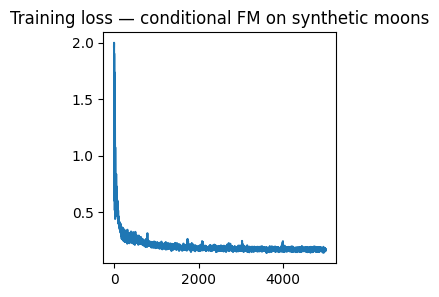

In [10]:
trainer.plot_training_logs()
plt.title("Training loss — conditional FM on synthetic moons")
plt.show()

## Section 7: Inference

We pass the **same source cells** to the model twice — once with condition A's
one-hot vector and once with condition B's. The model should push them to
different halves of the bottom moon.

In [11]:
# Retrieve source cells and both target populations
src_np = inner[("0",)].source_distribution.state_data.X.astype(np.float32)
tgt_a = inner[("0",)].target_distribution.state_data.X.astype(np.float32)  # left half
tgt_b = inner[("2",)].target_distribution.state_data.X.astype(np.float32)  # right half
src_t = torch.tensor(src_np)

# Build condition tensors — broadcast one-hot across all source cells
oh = adata.uns["labels"]
cond_a = torch.tensor(oh["0"], dtype=torch.float32).unsqueeze(0).expand(len(src_t), -1)
cond_b = torch.tensor(oh["2"], dtype=torch.float32).unsqueeze(0).expand(len(src_t), -1)

model.vf.eval()
with torch.no_grad():
    pred_a = model.predict(src_t, condition={"labels": cond_a}).numpy()
    pred_b = model.predict(src_t, condition={"labels": cond_b}).numpy()

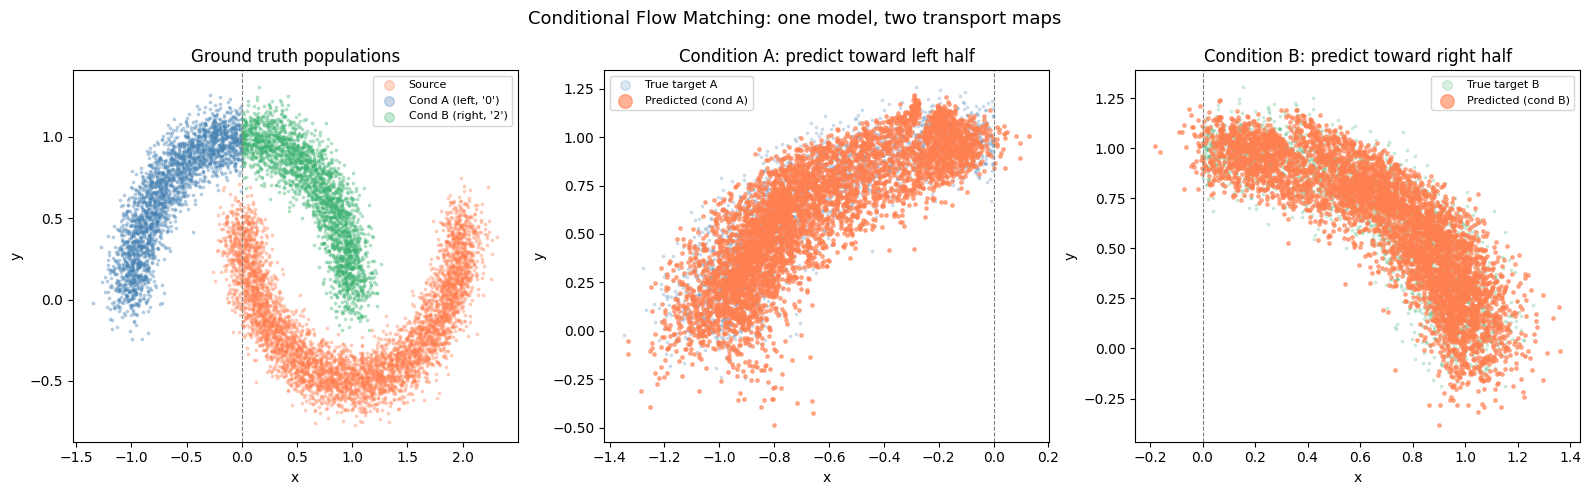

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Ground truth
axes[0].scatter(src_np[:, 0], src_np[:, 1], s=3, alpha=0.3, color="coral", label="Source")
axes[0].scatter(tgt_a[:, 0], tgt_a[:, 1], s=3, alpha=0.3, color="steelblue", label="Cond A (left, '0')")
axes[0].scatter(tgt_b[:, 0], tgt_b[:, 1], s=3, alpha=0.3, color="mediumseagreen", label="Cond B (right, '2')")
axes[0].axvline(0, color="gray", lw=0.8, linestyle="--")
axes[0].set_title("Ground truth populations")
axes[0].legend(markerscale=4, fontsize=8)

# Condition A predictions
axes[1].scatter(tgt_a[:, 0], tgt_a[:, 1], s=3, alpha=0.2, color="steelblue", label="True target A")
axes[1].scatter(pred_a[:, 0], pred_a[:, 1], s=6, alpha=0.6, color="coral", label="Predicted (cond A)")
axes[1].axvline(0, color="gray", lw=0.8, linestyle="--")
axes[1].set_title("Condition A: predict toward left half")
axes[1].legend(markerscale=4, fontsize=8)

# Condition B predictions
axes[2].scatter(tgt_b[:, 0], tgt_b[:, 1], s=3, alpha=0.2, color="mediumseagreen", label="True target B")
axes[2].scatter(pred_b[:, 0], pred_b[:, 1], s=6, alpha=0.6, color="coral", label="Predicted (cond B)")
axes[2].axvline(0, color="gray", lw=0.8, linestyle="--")
axes[2].set_title("Condition B: predict toward right half")
axes[2].legend(markerscale=4, fontsize=8)

for ax in axes:
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("Conditional Flow Matching: one model, two transport maps", fontsize=13)
plt.tight_layout()
plt.show()

## Section 8: ODE Trajectories


Under condition A the paths curve left; under condition B they curve right —
even though the starting point and the neural network weights are identical.
The only difference is the one-hot encoded conditions

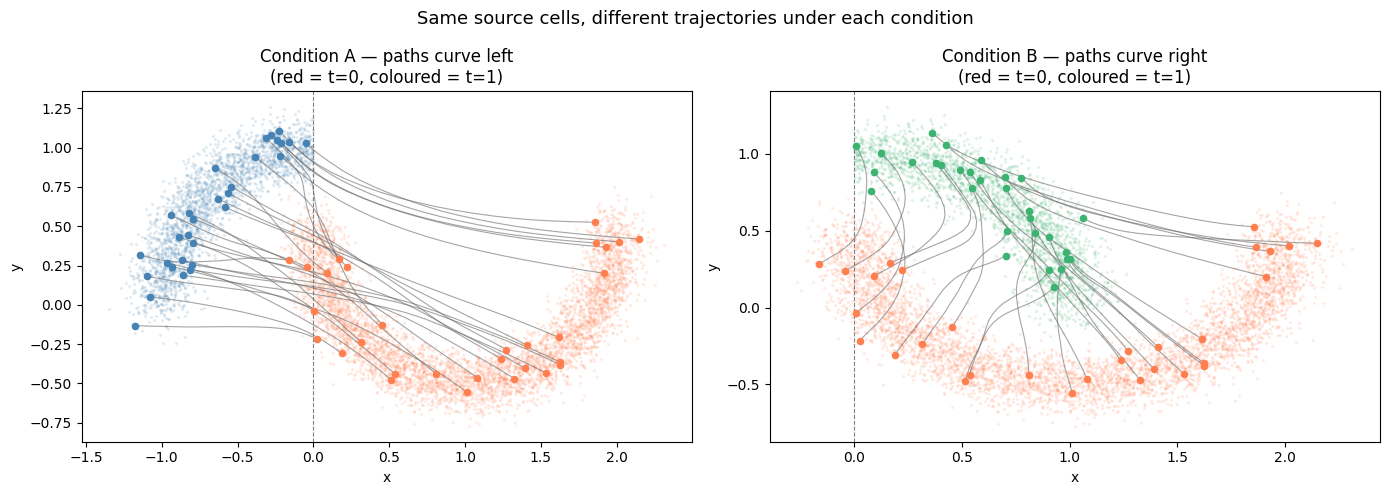

In [13]:
n_show = 30
src_small = src_t[:n_show]

model.vf.eval()
with torch.no_grad():
    cond_a_small = cond_a[:n_show]
    cond_b_small = cond_b[:n_show]
    traj_a = model.predict_trajectory(src_small, condition={"labels": cond_a_small}, n_steps=20)
    traj_b = model.predict_trajectory(src_small, condition={"labels": cond_b_small}, n_steps=20)

traj_a_np = traj_a.numpy()  # (n_steps, n_show, 2)
traj_b_np = traj_b.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, traj_np, tgt_np, title, tgt_color in [
    (axes[0], traj_a_np, tgt_a, "Condition A — paths curve left", "steelblue"),
    (axes[1], traj_b_np, tgt_b, "Condition B — paths curve right", "mediumseagreen"),
]:
    # Background: full source and target populations
    ax.scatter(src_np[:, 0], src_np[:, 1], s=2, alpha=0.1, color="coral")
    ax.scatter(tgt_np[:, 0], tgt_np[:, 1], s=2, alpha=0.1, color=tgt_color)
    ax.axvline(0, color="gray", lw=0.8, linestyle="--")

    # Trajectories for the n_show sampled cells
    for i in range(n_show):
        ax.plot(traj_np[:, i, 0], traj_np[:, i, 1], lw=0.8, alpha=0.6, color="dimgray")
        ax.scatter(traj_np[0, i, 0], traj_np[0, i, 1], s=20, color="coral", zorder=5)
        ax.scatter(traj_np[-1, i, 0], traj_np[-1, i, 1], s=20, color=tgt_color, zorder=5)

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"{title}\n(red = t=0, coloured = t=1)")

plt.suptitle("Same source cells, different trajectories under each condition", fontsize=13)
plt.tight_layout()
plt.show()

### What's next?

| Tutorial | What it introduces |
|---|---|
| [`210_conditional_fm_pbmc.ipynb`](210_conditional_fm_pbmc.ipynb) | Same concept on real PBMC data with 90 cytokine conditions and ESM2 embeddings |